## Utils.py


In [123]:
import pandas as pd
# Makes sure we see all columns
pd.set_option('display.max_columns', None)
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

class DataLoader():
    def __init__(self):
        self.data = None

    def load_dataset(self, path="data/healthcare-dataset-stroke-data.csv"):
        self.data = pd.read_csv(path)

    def preprocess_data(self):
        # One-hot encode all categorical columns
        categorical_cols = ["gender",
                            "ever_married",
                            "work_type",
                            "Residence_type",
                            "smoking_status"]
        encoded = pd.get_dummies(self.data[categorical_cols],
                                prefix=categorical_cols)

        # Update data with new columns
        self.data = pd.concat([encoded, self.data], axis=1)
        self.data.drop(categorical_cols, axis=1, inplace=True)

        # Impute missing values of BMI
        self.data.bmi = self.data.bmi.fillna(0)

        # Drop id as it is not relevant
        self.data.drop(["id"], axis=1, inplace=True)

        # Standardization
        # Usually we would standardize here and convert it back later
        # But for simplification we will not standardize / normalize the features

    def get_data_split(self):
        X = self.data.iloc[:,:-1]
        y = self.data.iloc[:,-1]
        return train_test_split(X, y, test_size=0.20, random_state=2021)

    def oversample(self, X_train, y_train):
        oversample = RandomOverSampler(sampling_strategy='minority')
        # Convert to numpy and oversample
        x_np = X_train.to_numpy()
        y_np = y_train.to_numpy()
        x_np, y_np = oversample.fit_resample(x_np, y_np)
        # Convert back to pandas
        x_over = pd.DataFrame(x_np, columns=X_train.columns)
        y_over = pd.Series(y_np, name=y_train.name)
        return x_over, y_over

In [124]:
import os
from google.colab import drive
drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/models"
os.makedirs(save_path, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [125]:
# %% Imports
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import copy
import pandas as pd
import random, os
import torch
import numpy as np

In [126]:
seed = 2021
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
# optional strict mode (can error on unsupported ops)
# torch.use_deterministic_algorithms(True)

In [127]:
# Set GPU device
# print(torch.cuda.is_available())
# device = torch.device("cuda:0")

# Set optional with CPU run
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# %% Load data
!git clone https://github.com/kezheonglim-ux/xai-brain-mri-assignment-2.git
# TRAIN_ROOT = "xai-series/data/brain_mri/training"
# TEST_ROOT = "xai-series/data/brain_mri/testing"
TRAIN_ROOT = "/content/xai-brain-mri-assignment-2/xai-series/data/brain_mri/training"
TEST_ROOT  = "/content/xai-brain-mri-assignment-2/xai-series/data/brain_mri/testing"
train_dataset = torchvision.datasets.ImageFolder(root=TRAIN_ROOT)
test_dataset = torchvision.datasets.ImageFolder(root=TEST_ROOT)

Using device: cpu
fatal: destination path 'xai-brain-mri-assignment-2' already exists and is not an empty directory.


In [128]:
# %% Building the model
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.vgg16 = models.vgg16(pretrained=True)

        # Replace output layer according to our problem
        in_feats = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(in_feats, 4)

    def forward(self, x):
        x = self.vgg16(x)
        return x

model = CNNModel()
model.to(device)
model

# %% Prepare data for pretrained model
train_dataset = torchvision.datasets.ImageFolder(
        root=TRAIN_ROOT,
        transform=transforms.Compose([
                      transforms.Resize((255,255)),
                      transforms.ToTensor()
        ])
)

test_dataset = torchvision.datasets.ImageFolder(
        root=TEST_ROOT,
        transform=transforms.Compose([
                      transforms.Resize((255,255)),
                      transforms.ToTensor()
        ])
)

#train_dataset[0][0].permute(1,2,0)

# %% Create data loaders
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True
)



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [164]:
print(f"Total training samples: {len(train_dataset)}")
print(f"Total training samples: {len(test_dataset)}")

Total training samples: 2771
Total training samples: 394


## Can igonre rerun the model by using previous save model at next cell

In [ ]:
# %% Train
cross_entropy_loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00001)
epochs = 10

# Iterate x epochs over the train data
for epoch in range(epochs):
    for i, batch in enumerate(train_loader, 0):
        inputs, labels = batch
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        # Labels are automatically one-hot-encoded
        loss = cross_entropy_loss(outputs, labels)
        loss.backward()
        optimizer.step()
        print(loss)
    torch.save(model.state_dict(), f"{save_path}/vgg16_epoch_{epoch}.pth")

## Load the last generate epoch(9) for faster model load

In [157]:
# Define the specific file path
# Change 'vgg16_epoch10.pth' to the exact name you saw in the list above
model_file = os.path.join(save_path, 'vgg16_epoch_9.pth')

# Load the file
# map_location=device ensures it loads correctly to your current GPU/CPU
checkpoint = torch.load(model_file, map_location=device)

# Check if it's a state_dict or a full checkpoint dictionary
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded full checkpoint from {model_file}")
else:
    model.load_state_dict(checkpoint)
    print(f"Loaded state_dict from {model_file}")

model.eval() # Set to evaluation mode for Grad-CAM/LRP

Loaded state_dict from /content/drive/MyDrive/models/vgg16_epoch_9.pth


CNNModel(
  (vgg16): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU()
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU()
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU()
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU()
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU()
      (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1

In [158]:
# %% Inspect predictions for first batch
import pandas as pd
inputs, labels = next(iter(test_loader))
inputs = inputs.to(device)
labels = labels.numpy()
outputs = model(inputs).max(1).indices.detach().cpu().numpy()
comparison = pd.DataFrame()
print("Batch accuracy: ", (labels==outputs).sum()/len(labels))
comparison["labels"] = labels

comparison["outputs"] = outputs
comparison

# %% Layerwise relevance propagation for VGG16
# For other CNN architectures this code might become more complex
# Source: https://git.tu-berlin.de/gmontavon/lrp-tutorial
# http://iphome.hhi.de/samek/pdf/MonXAI19.pdf

def new_layer(layer, g):
    """Clone a layer and pass its parameters through the function g."""
    layer = copy.deepcopy(layer)
    try: layer.weight = torch.nn.Parameter(g(layer.weight))
    except AttributeError: pass
    try: layer.bias = torch.nn.Parameter(g(layer.bias))
    except AttributeError: pass
    return layer

def dense_to_conv(layers):
    """ Converts a dense layer to a conv layer """
    newlayers = []
    for i,layer in enumerate(layers):
        if isinstance(layer, nn.Linear):
            newlayer = None
            if i == 0:
                m, n = 512, layer.weight.shape[0]
                newlayer = nn.Conv2d(m,n,7)
                newlayer.weight = nn.Parameter(layer.weight.reshape(n,m,7,7))
            else:
                m,n = layer.weight.shape[1],layer.weight.shape[0]
                newlayer = nn.Conv2d(m,n,1)
                newlayer.weight = nn.Parameter(layer.weight.reshape(n,m,1,1))
            newlayer.bias = nn.Parameter(layer.bias)
            newlayers += [newlayer]
        else:
            newlayers += [layer]
    return newlayers

def get_linear_layer_indices(model):
    offset = len(model.vgg16._modules['features']) + 1
    indices = []
    for i, layer in enumerate(model.vgg16._modules['classifier']):
        if isinstance(layer, nn.Linear):
            indices.append(i)
    indices = [offset + val for val in indices]
    return indices

def apply_lrp_on_vgg16(model, image):
    image = torch.unsqueeze(image, 0)
    # >>> Step 1: Extract layers
    layers = list(model.vgg16._modules['features']) \
                + [model.vgg16._modules['avgpool']] \
                + dense_to_conv(list(model.vgg16._modules['classifier']))
    linear_layer_indices = get_linear_layer_indices(model)
    # >>> Step 2: Propagate image through layers and store activations
    n_layers = len(layers)
    activations = [image] + [None] * n_layers # list of activations

    for layer in range(n_layers):
        if layer in linear_layer_indices:
            if layer == 32:
                activations[layer] = activations[layer].reshape((1, 512, 7, 7))
        activation = layers[layer].forward(activations[layer])
        if isinstance(layers[layer], torch.nn.modules.pooling.AdaptiveAvgPool2d):
            activation = torch.flatten(activation, start_dim=1)
        activations[layer+1] = activation

    # >>> Step 3: Replace last layer with one-hot-encoding
    output_activation = activations[-1].detach().cpu().numpy()
    max_activation = output_activation.max()
    one_hot_output = [val if val == max_activation else 0
                        for val in output_activation[0]]

    activations[-1] = torch.FloatTensor([one_hot_output]).to(device)

    # >>> Step 4: Backpropagate relevance scores
    relevances = [None] * n_layers + [activations[-1]]
    # Iterate over the layers in reverse order
    for layer in range(0, n_layers)[::-1]:
        current = layers[layer]
        # Treat max pooling layers as avg pooling
        if isinstance(current, torch.nn.MaxPool2d):
            layers[layer] = torch.nn.AvgPool2d(2)
            current = layers[layer]
        if isinstance(current, torch.nn.Conv2d) or \
           isinstance(current, torch.nn.AvgPool2d) or\
           isinstance(current, torch.nn.Linear):
            activations[layer] = activations[layer].data.requires_grad_(True)

            # Apply variants of LRP depending on the depth
            # see: https://link.springer.com/chapter/10.1007%2F978-3-030-28954-6_10
            # Lower layers, LRP-gamma >> Favor positive contributions (activations)
            if layer <= 16:       rho = lambda p: p + 0.25*p.clamp(min=0); incr = lambda z: z+1e-9
            # Middle layers, LRP-epsilon >> Remove some noise / Only most salient factors survive
            if 17 <= layer <= 30: rho = lambda p: p;                       incr = lambda z: z+1e-9+0.25*((z**2).mean()**.5).data
            # Upper Layers, LRP-0 >> Basic rule
            if layer >= 31:       rho = lambda p: p;                       incr = lambda z: z+1e-9

            # Transform weights of layer and execute forward pass
            z = incr(new_layer(layers[layer],rho).forward(activations[layer]))
            # Element-wise division between relevance of the next layer and z
            s = (relevances[layer+1]/z).data
            # Calculate the gradient and multiply it by the activation
            (z * s).sum().backward();
            c = activations[layer].grad
            # Assign new relevance values
            relevances[layer] = (activations[layer]*c).data
        else:
            relevances[layer] = relevances[layer+1]

    # >>> Potential Step 5: Apply different propagation rule for pixels
    return relevances[0]

Batch accuracy:  0.65625


# LRP

In [159]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

def lrp_linear(layer, R, x, eps=1e-6):
    w = layer.weight
    b = layer.bias if layer.bias is not None else 0

    z = torch.matmul(x, w.t()) + b
    z += eps * torch.where(z >= 0, torch.ones_like(z), -torch.ones_like(z))

    s = R / z
    c = torch.matmul(s, w)
    return x * c


# def lrp_conv(layer, R, x, eps=1e-6):
#     z = nn.functional.conv2d(
#         x, layer.weight, layer.bias,
#         stride=layer.stride,
#         padding=layer.padding
#     )
#     z += eps * torch.where(z >= 0, torch.ones_like(z), -torch.ones_like(z))

#     s = R / z
#     c = nn.functional.conv_transpose2d(
#         s, layer.weight,
#         stride=layer.stride,
#         padding=layer.padding
#     )
#     return x * c

def lrp_conv(layer, R, x):
    # This version focuses on the most influential pixels
    w = torch.clamp(layer.weight, min=0) # Only consider positive weights
    z = nn.functional.conv2d(x, w, bias=None, stride=layer.stride, padding=layer.padding) + 1e-9
    s = R / z
    c = nn.functional.conv_transpose2d(s, w, stride=layer.stride, padding=layer.padding)
    return x * c

In [160]:
class LRP:
    def __init__(self, model):
        self.model = model
        self.model.eval()

    def forward(self, x):
        self.activations = [x]
        # 1. Features (Convolutional layers)
        for layer in self.model.vgg16.features:
            x = layer(x)
            self.activations.append(x)

        # Save the shape [Batch, 512, 7, 7] before flattening
        self.shape_before_flatten = x.shape

        # 2. Flatten for the classifier
        x = torch.flatten(x, 1)

        # 3. Classifier (Linear layers)
        for layer in self.model.vgg16.classifier:
            x = layer(x)
            self.activations.append(x)
        return x

    def explain(self, x, target_class=None):
        logits = self.forward(x)

        if target_class is None:
            target_class = logits.argmax(dim=1).item()

        # Initialize Relevance R
        R = torch.zeros_like(logits)
        R[:, target_class] = logits[:, target_class]

        # Pop the output logits
        self.activations.pop()

        # 1. Backward through Classifier
        for layer in reversed(self.model.vgg16.classifier):
            a = self.activations.pop() # Get input to this layer
            if isinstance(layer, nn.Linear):
                # Ensure activation is flattened for Linear layers
                if len(a.shape) > 2:
                    a = torch.flatten(a, 1)
                R = lrp_linear(layer, R, a)

        # 2. Bridge: Reshape R from flattened [1, 25088] back to [1, 512, 7, 7]
        R = R.view(self.shape_before_flatten)

        # 3. Backward through Features
        for layer in reversed(self.model.vgg16.features):
            a = self.activations.pop() # Get input to this layer
            if isinstance(layer, nn.Conv2d):
                R = lrp_conv(layer, R, a)
            elif isinstance(layer, nn.ReLU):
                R = torch.clamp(R, min=0)
            elif isinstance(layer, nn.MaxPool2d):
                # Upsample relevance back to the size of the input activation
                R = nn.functional.interpolate(R, size=(a.shape[2], a.shape[3]), mode="nearest")

        return R.sum(dim=1).detach().cpu().numpy()[0]

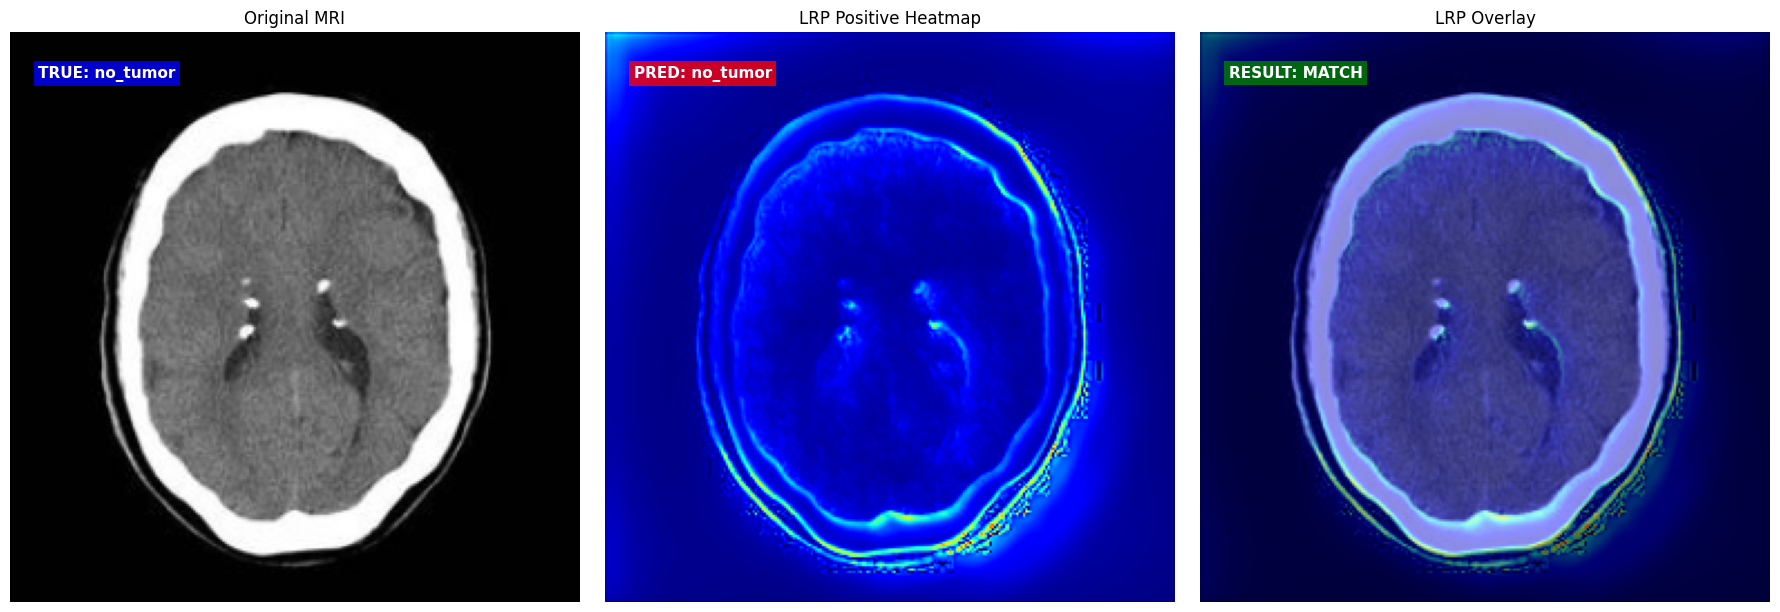

In [161]:
import scipy.ndimage as ndimage
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETUP DATA & GENERATE LRP ---
image_id = 31
x = inputs[image_id:image_id+1].to(device)

lrp = LRP(model)
logits = lrp.forward(x)
relevance_map = lrp.explain(x) # Now relevance_map is defined!

# --- 2. SMOOTHING & AMPLIFICATION (The Fix) ---
# Apply blur to connect the dots and focus on the tumor mass
# smoothed_relevance = ndimage.gaussian_filter(relevance_map, sigma=2.5)

# Focus on positive features (ReLU) and apply Power-law (Gamma)
# lrp_pos = np.maximum(0, smoothed_relevance)
# lrp_pos = np.power(lrp_pos, 0.7) # Makes the heatmap look "fuller"

# --- 2. RAW PIXEL RELEVANCE (Gaussian Filter Removed) ---
# Use the raw relevance map directly to see pixel-level detail
lrp_pos = np.maximum(0, relevance_map)


# Final Normalization for display [0, 1]
lrp_pos = (lrp_pos - lrp_pos.min()) / (lrp_pos.max() - lrp_pos.min() + 1e-8)

# --- 3. PROCESS LABELS ---
idx_to_class = {v: k for k, v in test_dataset.class_to_idx.items()}
pred_name = idx_to_class[logits.argmax(dim=1).item()]
gt_name = idx_to_class[labels[image_id].item()]
is_match = (pred_name == gt_name)

# --- 4. PREPARE ORIGINAL MRI ---
img_raw = x[0].permute(1, 2, 0).cpu().numpy()
img_norm = (img_raw - img_raw.min()) / (img_raw.max() - img_raw.min() + 1e-8)

# --- 5. PLOTTING ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

label_style = {'color': 'white', 'fontweight': 'bold', 'fontsize': 11}
bbox_style = {'alpha': 0.8, 'edgecolor': 'none', 'pad': 3}

# Panel 1: Original
axes[0].imshow(img_norm)
axes[0].set_title("Original MRI")
axes[0].text(0.05, 0.92, f"TRUE: {gt_name}", transform=axes[0].transAxes,
             **label_style, bbox=dict(facecolor='blue', **bbox_style))
axes[0].axis('off')

# Panel 2: Heatmap
axes[1].imshow(lrp_pos, cmap='jet')
axes[1].set_title("LRP Positive Heatmap")
axes[1].text(0.05, 0.92, f"PRED: {pred_name}", transform=axes[1].transAxes,
             **label_style, bbox=dict(facecolor='red', **bbox_style))
axes[1].axis('off')

# Panel 3: Overlay
axes[2].imshow(img_norm)
axes[2].imshow(lrp_pos, cmap='jet', alpha=0.45)
axes[2].set_title("LRP Overlay")
res_text = "RESULT: MATCH" if is_match else "RESULT: MISMATCH"
res_color = 'green' if is_match else 'black'
axes[2].text(0.05, 0.92, res_text, transform=axes[2].transAxes,
             **label_style, bbox=dict(facecolor=res_color, **bbox_style))
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Grad-CAM

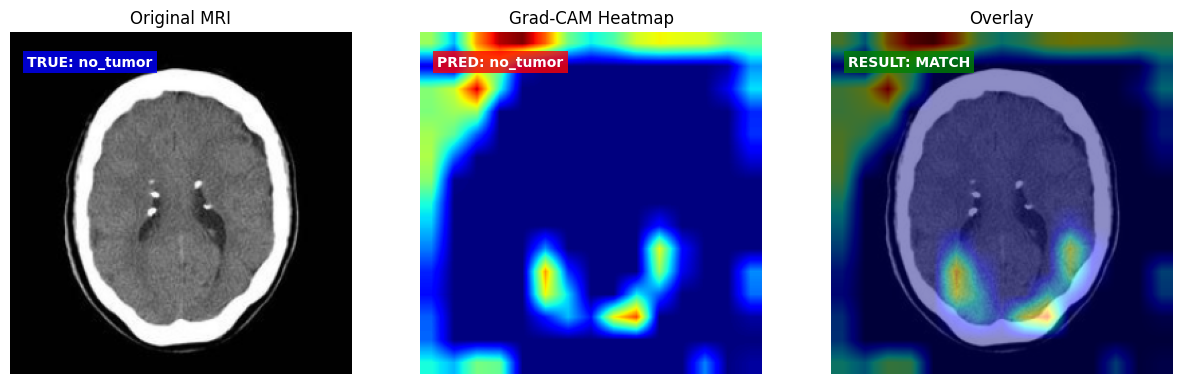

In [162]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# --- STEP 1: DEFINE THE CLASS FIRST ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, out):
            self.activations = out.detach()

        def backward_hook(module, grad_in, grad_out):
            if grad_out[0] is not None:
                self.gradients = grad_out[0].detach().clone()
            else:
                self.gradients = None

        self.hook_handles.append(self.target_layer.register_forward_hook(forward_hook))
        if hasattr(self.target_layer, "register_full_backward_hook"):
            self.hook_handles.append(self.target_layer.register_full_backward_hook(backward_hook))
        else:
            self.hook_handles.append(self.target_layer.register_backward_hook(backward_hook))

    def remove_hooks(self):
        for h in self.hook_handles:
            h.remove()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        self.model.zero_grad(set_to_none=True)
        score = logits[:, class_idx].sum()
        score.backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=False)
        cam = F.relu(cam)

        # Normalize Heatmap
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        # Resize CAM to match input image size (e.g., 224x224)
        cam = F.interpolate(cam.unsqueeze(1), size=(x.shape[2], x.shape[3]), mode='bilinear', align_corners=False)
        return cam.detach().cpu().numpy()[0, 0], class_idx

# --- STEP 2: SETUP & RUN ---
# Fix inplace ReLUs for VGG16
for module in model.modules():
    if isinstance(module, torch.nn.ReLU):
        module.inplace = False

target_layer = model.vgg16.features[28]
gradcam = GradCAM(model, target_layer)

# Select image
image_id = 31
x = inputs[image_id:image_id+1].to(device)
cam, pred_class = gradcam(x)

# Decode Labels
idx_to_class = {v: k for k, v in test_dataset.class_to_idx.items()}
pred_name = idx_to_class[pred_class]
gt_name = idx_to_class[labels[image_id].item()]
is_match = (pred_name == gt_name)

# --- STEP 3: VISUALIZE WITH ON-IMAGE LABELS ---
img_raw = x[0].permute(1, 2, 0).cpu().numpy()
img_norm = (img_raw - img_raw.min()) / (img_raw.max() - img_raw.min() + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
label_style = {'color': 'white', 'fontweight': 'bold', 'fontsize': 10}
bbox_style = {'alpha': 0.8, 'edgecolor': 'none', 'pad': 3}

# Panel 1: Original
axes[0].imshow(img_norm)
axes[0].set_title("Original MRI")
axes[0].text(0.05, 0.9, f"TRUE: {gt_name}", transform=axes[0].transAxes,
             **label_style, bbox=dict(facecolor='blue', **bbox_style))
axes[0].axis('off')

# Panel 2: Heatmap
axes[1].imshow(cam, cmap='jet')
axes[1].set_title("Grad-CAM Heatmap")
axes[1].text(0.05, 0.9, f"PRED: {pred_name}", transform=axes[1].transAxes,
             **label_style, bbox=dict(facecolor='red', **bbox_style))
axes[1].axis('off')

# Panel 3: Overlay
axes[2].imshow(img_norm)
axes[2].imshow(cam, cmap='jet', alpha=0.45)
axes[2].set_title("Overlay")
res_text = "RESULT: MATCH" if is_match else "RESULT: MISMATCH"
res_color = 'green' if is_match else 'black'
axes[2].text(0.05, 0.9, res_text, transform=axes[2].transAxes,
             **label_style, bbox=dict(facecolor=res_color, **bbox_style))
axes[2].axis('off')

plt.show()
gradcam.remove_hooks()